# Fama-French 5-Factor Data: Loading & Exploration

**Project:** ML-based cross-sectional equity return prediction (Project #1)
**This notebook:** Load, clean, and explore the Fama-French 5 research factors, used later as the benchmark for alpha attribution.

**Data source:** Kenneth R. French Data Library: F-F Research Data 5 Factors (2*3), monthly.

**Steps:**
1. Load raw CSV
2. Clean (drop annual-data tail & copyright rows, filter to monthly YYYYMM rows)
3. Convert to numeric, handle missing codes, scale to decimals, set datetime index
4. Plot cumulative factor returns

In [1]:
import pandas as pd
import os
print(os.getcwd())

C:\Users\AEQJR\Documents\quant_finance_project\fama_french_ML_stock\ff5-ml-alpha


In [2]:
ff5_raw = pd.read_csv("data/F-F_Research_Data_5_Factors_2x3.csv", skiprows=4)

In [3]:
print(ff5_raw.head(15))
print("...")
print("...")
print(ff5_raw.tail(15))
print("shape:",ff5_raw.shape)

   Unnamed: 0 Mkt-RF    SMB    HML    RMW    CMA    RF
0      196307  -0.39  -0.48  -0.81   0.64  -1.15  0.27
1      196308   5.08   -0.8    1.7    0.4  -0.38  0.25
2      196309  -1.57  -0.43      0  -0.78   0.15  0.27
3      196310   2.54  -1.34  -0.04   2.79  -2.25  0.29
4      196311  -0.86  -0.85   1.73  -0.43   2.27  0.27
5      196312   1.83  -1.89  -0.21   0.12  -0.25  0.29
6      196401   2.27    0.1   1.63   0.21   1.48   0.3
7      196402   1.55   0.33   2.81   0.11   0.81  0.26
8      196403   1.41   1.41   3.29  -2.03   2.98  0.31
9      196404   0.11  -1.48  -0.54  -1.32  -1.13  0.29
10     196405   1.41  -0.62   1.81  -0.15   0.13  0.26
11     196406   1.27   0.13   0.68  -0.33    0.1   0.3
12     196407   1.74    0.5   0.79   0.15   1.85   0.3
13     196408  -1.44   0.29   0.07   0.15   0.31  0.28
14     196409   2.69  -0.34   1.72   -0.5   0.56  0.28
...
...
                                            Unnamed: 0  Mkt-RF     SMB  \
808                                   

In [4]:
ff5 = ff5_raw.rename(columns={'Unnamed: 0': 'date'})
ff5['date']=ff5['date'].astype(str).str.strip()
ff5 =ff5[ff5['date'].str.match(r'^\d{6}$')].copy()
print(ff5.tail())
print("shape after data cleaning:",ff5.shape)

       date Mkt-RF    SMB    HML    RMW    CMA    RF
751  202602  -1.18   0.74   2.71   1.91   5.04  0.28
752  202603  -5.18   0.66   3.41  -2.08   -0.1  0.29
753  202604   9.95   0.38  -1.17   -4.3  -3.78  0.29
754  202605   4.91  -2.77  -2.16  -8.42   -1.4  0.31
755  202606  -1.07   4.58   3.34  -4.64   3.46  0.29
shape after data cleaning: (756, 7)


In [5]:
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff5[factor_cols] = ff5[factor_cols].apply(pd.to_numeric, errors='coerce')
import numpy as np
ff5[factor_cols] = ff5[factor_cols].replace(-99.99, np.nan)
ff5[factor_cols] = ff5[factor_cols] / 100
print(ff5.head())
print(ff5.isna().sum())

     date  Mkt-RF     SMB     HML     RMW     CMA      RF
0  196307 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0027
1  196308  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0025
2  196309 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0027
3  196310  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0029
4  196311 -0.0086 -0.0085  0.0173 -0.0043  0.0227  0.0027
date      0
Mkt-RF    0
SMB       0
HML       0
RMW       0
CMA       0
RF        0
dtype: int64


In [6]:
ff5['date']=pd.to_datetime(ff5['date'], format = '%Y%m')
ff5 = ff5.set_index('date')
print(ff5.head())
print(ff5.index)

            Mkt-RF     SMB     HML     RMW     CMA      RF
date                                                      
1963-07-01 -0.0039 -0.0048 -0.0081  0.0064 -0.0115  0.0027
1963-08-01  0.0508 -0.0080  0.0170  0.0040 -0.0038  0.0025
1963-09-01 -0.0157 -0.0043  0.0000 -0.0078  0.0015  0.0027
1963-10-01  0.0254 -0.0134 -0.0004  0.0279 -0.0225  0.0029
1963-11-01 -0.0086 -0.0085  0.0173 -0.0043  0.0227  0.0027
DatetimeIndex(['1963-07-01', '1963-08-01', '1963-09-01', '1963-10-01',
               '1963-11-01', '1963-12-01', '1964-01-01', '1964-02-01',
               '1964-03-01', '1964-04-01',
               ...
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
               '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01'],
              dtype='datetime64[us]', name='date', length=756, freq=None)


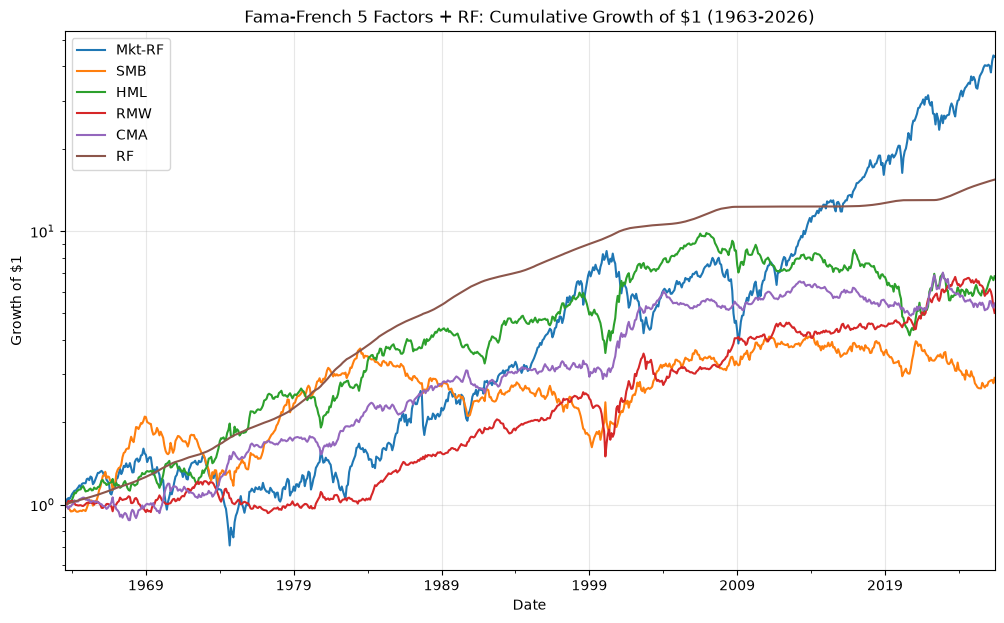

In [7]:
import matplotlib.pyplot as plt
cumulative = (1+ff5[factor_cols]).cumprod()
cumulative.plot(figsize=(12, 7))
plt.title('Fama-French 5 Factors + RF: Cumulative Growth of $1 (1963-2026)')
plt.ylabel('Growth of $1')
plt.xlabel('Date')
plt.yscale('log')
plt.grid(True, alpha = 0.3)
plt.savefig('figures/ff5_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()